In [71]:
#!/usr/bin/env python3

import xml.etree.ElementTree as ET
from pathlib import Path
import pandas as pd

INTERACTION_TYPES = [
    "hydrophobic_interactions",
    "hydrogen_bonds",
    "water_bridges",
    "salt_bridges",
    "pi_stacks",
    "pi_cation_interactions",
    "halogen_bonds",
    "metal_complexes",
]

rows = []

for xml_file in Path(".").glob("*.xml"):

    protein, ligand = xml_file.stem.rsplit("_", 1)
    if protein == "PDE4B_CATALYTIC":
        next
    else:
        root = ET.parse(xml_file).getroot()

        for bs in root.findall("bindingsite"):

            identifiers = bs.find("identifiers")
            ligtype = identifiers.findtext("ligtype")

            # ignore metal ions
            if ligtype == "ION":
                continue

            interactions = bs.find("interactions")

            for interaction_group in INTERACTION_TYPES:

                group = interactions.find(interaction_group)

                if group is None:
                    continue

                for interaction in group:

                    rows.append(
                        {
                            "protein": protein,
                            "ligand": ligand,
                            "interaction_type": interaction_group,
                            "residue": interaction.findtext("resnr"),
                            "restype": interaction.findtext("restype"),
                            "chain": interaction.findtext("reschain"),
                        }
                    )

df = pd.DataFrame(rows)

In [72]:
mapping = {
    "PDE4D_CATALYTIC": "PDE4D_catalytic",
    "PDE4B_CATALYTIC2": "PDE4B_catalytic",
    "PDE4B_MONOMER": "PDE4B_monomer",
    "PDE4B_DIMER": "PDE4B_dimer"
}

df["protein"] = df["protein"].map(mapping)

In [73]:
df["protein"].value_counts()

protein
PDE4D_catalytic    110
PDE4B_catalytic    104
PDE4B_monomer      102
PDE4B_dimer         97
Name: count, dtype: int64

In [74]:
df["residue_id"] = (
    df["restype"] + df["residue"] + df["chain"]
)

df.to_csv("plip_interactions.csv", index=False)

print(f"\nTotal interactions: {len(df)}")
print(f"Unique ligands: {df['ligand'].nunique()}")
print(f"Unique residues: {df['residue_id'].nunique()}")


Total interactions: 413
Unique ligands: 12
Unique residues: 45


In [75]:
conserved = (
    df.groupby(["protein", "residue_id"])["ligand"]
      .nunique()
      .reset_index(name="n_ligands")
      .sort_values("n_ligands", ascending=False)
)

print(conserved.head(20))

            protein residue_id  n_ligands
56  PDE4D_catalytic    PHE618A         12
44    PDE4B_monomer    PHE618A         12
37    PDE4B_monomer    ARG296A         12
61  PDE4D_catalytic    TYR405A         12
0   PDE4B_catalytic    ASN567A         10
13  PDE4B_catalytic    TYR575A         10
53  PDE4D_catalytic    ILE582A         10
50  PDE4D_catalytic    GLN615A         10
41    PDE4B_monomer    ILE582A         10
32      PDE4B_dimer    SER276A          9
2   PDE4B_catalytic    GLN615A          9
10  PDE4B_catalytic    PHE618A          9
51  PDE4D_catalytic    HIS406A          9
28      PDE4B_dimer    LYS508A          8
14  PDE4B_catalytic    VAL623A          8
36      PDE4B_dimer    VAL286A          8
60  PDE4D_catalytic    TRP578A          8
16      PDE4B_dimer    ASN255A          7
35      PDE4B_dimer    TYR549A          7
40    PDE4B_monomer    GLU585A          7


In [76]:
fp = (
    df.assign(value=1)
      .pivot_table(
          index=["protein", "ligand"],
          columns="residue_id",
          values="value",
          fill_value=0
      )
)

fp.to_csv("interaction_fingerprint.csv")

In [77]:
known = ["ROLIPRAM", "ROFLUMILAST"]

known_fp = fp.loc[
    fp.index.get_level_values("ligand").isin(known)
]

conserved = known_fp.sum(axis=0) == len(known_fp)

print(conserved[conserved].index.tolist())

[]


In [32]:
known_fp

residue_id                   ARG296A  ASN567A  ASP447A  ASP564A  GLN615A  \
protein         ligand                                                     
PDE4B_catalytic ROFLUMILAST      0.0      1.0      0.0      1.0      0.0   
                ROLIPRAM         0.0      0.0      0.0      0.0      0.0   
PDE4B_monomer   ROFLUMILAST      1.0      0.0      0.0      0.0      0.0   
                ROLIPRAM         1.0      0.0      0.0      0.0      0.0   
PDE4D_catalytic ROFLUMILAST      0.0      0.0      0.0      0.0      1.0   
                ROLIPRAM         0.0      0.0      0.0      0.0      1.0   

residue_id                   GLU585A  HIS406A  HIS410A  HIS450A  ILE582A  ...  \
protein         ligand                                                    ...   
PDE4B_catalytic ROFLUMILAST      0.0      1.0      0.0      1.0      1.0  ...   
                ROLIPRAM         0.0      0.0      0.0      0.0      0.0  ...   
PDE4B_monomer   ROFLUMILAST      1.0      0.0      0.0      0.0      1.0  ...   
                ROLIPRAM         1.0      0.0      0.0      0.0      1.0  ...   
PDE4D_catalytic ROFLUMILAST      0.0      1.0      0.0      0.0      0.0  ...   
                ROLIPRAM         0.0      1.0      0.0      0.0      1.0  ...   

residue_id                   PHE586A  PHE618A  PRO568A  SER614A  THR517A  \
protein         ligand                                                     
PDE4B_catalytic ROFLUMILAST      0.0      0.0      0.0      0.0      0.0   
                ROLIPRAM         0.0      1.0      0.0      0.0      0.0   
PDE4B_monomer   ROFLUMILAST      1.0      1.0      0.0      0.0      0.0   
                ROLIPRAM         1.0      1.0      0.0      0.0      0.0   
PDE4D_catalytic ROFLUMILAST      0.0      1.0      0.0      0.0      0.0   
                ROLIPRAM         1.0      1.0      0.0      0.0      0.0   

residue_id                   THR579A  TRP578A  TYR405A  TYR575A  VAL623A  
protein         ligand                                                    
PDE4B_catalytic ROFLUMILAST      0.0      0.0      0.0      1.0      0.0  
                ROLIPRAM         0.0      0.0      0.0      1.0      1.0  
PDE4B_monomer   ROFLUMILAST      0.0      0.0      1.0      0.0      0.0  
                ROLIPRAM         0.0      0.0      1.0      0.0      0.0  
PDE4D_catalytic ROFLUMILAST      1.0      0.0      1.0      1.0      0.0  
                ROLIPRAM         0.0      0.0      1.0      0.0      0.0  

[6 rows x 23 columns]

In [78]:
from sklearn.metrics import jaccard_score

reference = fp.loc[("PDE4B_catalytic", "ROLIPRAM")]

similar = []

for idx, row in fp.iterrows():

    similarity = jaccard_score(reference, row)

    similar.append((idx, round(similarity, 2)))

    #print(idx, round(similarity, 2))

In [79]:
similar.sort(key=lambda x: x[1], reverse=True)
similar

[(('PDE4B_catalytic', 'ROLIPRAM'), 1.0),
 (('PDE4B_catalytic', '107'), 0.5),
 (('PDE4B_catalytic', 'NO13'), 0.5),
 (('PDE4B_catalytic', 'NO17'), 0.5),
 (('PDE4B_catalytic', '10559720'), 0.38),
 (('PDE4B_catalytic', 'NO12'), 0.33),
 (('PDE4D_catalytic', 'ROFLUMILAST'), 0.29),
 (('PDE4B_catalytic', '49831816'), 0.25),
 (('PDE4B_catalytic', 'NO7'), 0.22),
 (('PDE4B_catalytic', '6047'), 0.2),
 (('PDE4B_catalytic', '104775'), 0.17),
 (('PDE4B_monomer', '104775'), 0.17),
 (('PDE4B_monomer', '107'), 0.17),
 (('PDE4B_monomer', '348154'), 0.17),
 (('PDE4B_monomer', 'NO7'), 0.17),
 (('PDE4D_catalytic', '104775'), 0.17),
 (('PDE4B_monomer', '49831816'), 0.14),
 (('PDE4B_monomer', 'NO12'), 0.14),
 (('PDE4B_monomer', 'NO17'), 0.14),
 (('PDE4D_catalytic', '107'), 0.14),
 (('PDE4B_catalytic', '348154'), 0.12),
 (('PDE4B_catalytic', 'ROFLUMILAST'), 0.12),
 (('PDE4B_monomer', '6047'), 0.12),
 (('PDE4B_monomer', 'NO13'), 0.12),
 (('PDE4B_monomer', 'ROFLUMILAST'), 0.12),
 (('PDE4B_monomer', 'ROLIPRAM'), 

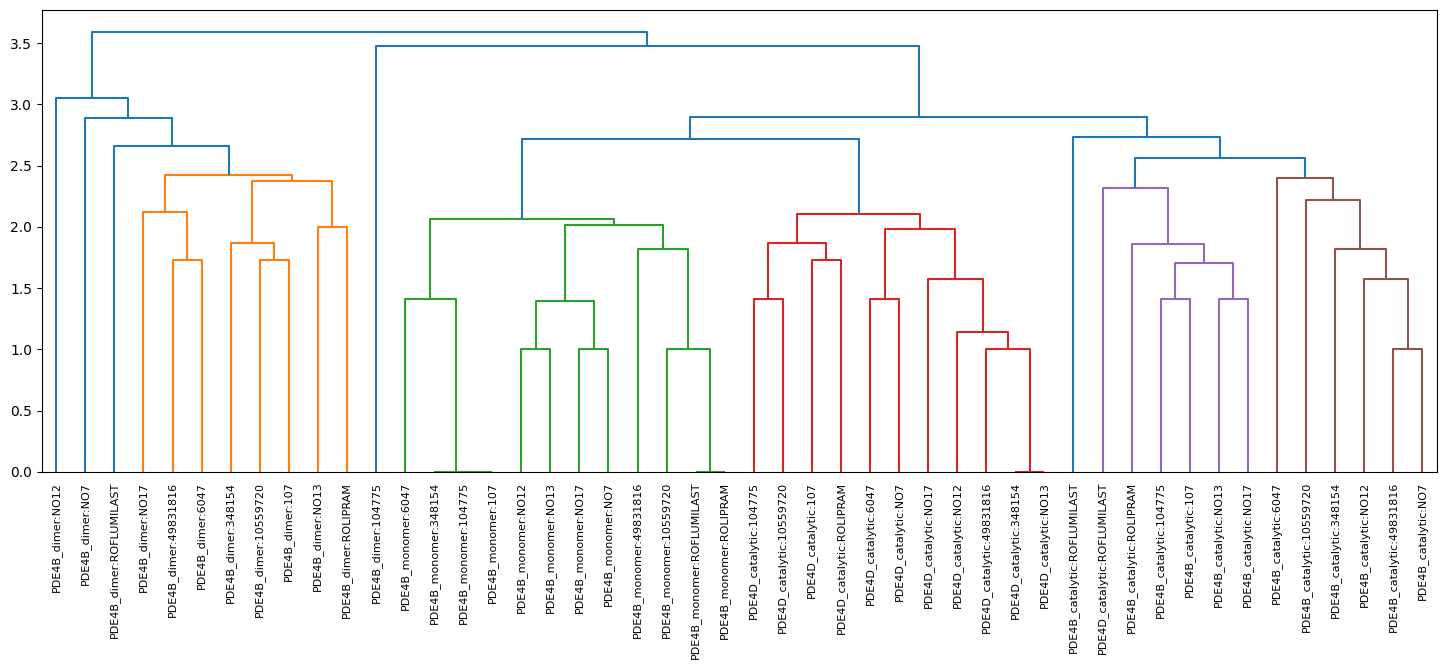

In [80]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(fp.values, method="average")

plt.figure(figsize=(18,6))
dendrogram(
    Z,
    labels=[f"{p}:{l}" for p,l in fp.index]
)
plt.show()

In [81]:
residue_sets = {
    protein: set(sub["residue_id"])
    for protein, sub in df.groupby("protein")
}

pde4b_cat = residue_sets["PDE4B_catalytic"]
pde4b_mono = residue_sets["PDE4B_monomer"]
pde4d = residue_sets["PDE4D_catalytic"]
pde4b_dimer = residue_sets["PDE4B_dimer"]


In [82]:

print("Shared mono e dimer:")
print(sorted(pde4b_mono & pde4b_dimer))

print("\nOnly PDE4B mono:")
print(sorted(pde4b_mono - pde4b_dimer))

print("\nOnly PDE4B dimer:")
print(sorted(pde4b_dimer - pde4b_mono))

Shared mono e dimer:
[]

Only PDE4B mono:
['ARG296A', 'ASN567A', 'ASP564A', 'GLU585A', 'ILE582A', 'LYS298A', 'PHE586A', 'PHE618A', 'SER614A', 'THR579A', 'TYR405A']

Only PDE4B dimer:
['ARG507A', 'ASN255A', 'ASN277B', 'ASP281B', 'ASP285B', 'ASP512A', 'GLN283B', 'GLU273A', 'ILE511A', 'LEU254B', 'LEU258A', 'LYS251B', 'LYS282B', 'LYS508A', 'PHE250A', 'SER262A', 'SER272A', 'SER276A', 'THR259A', 'THR278B', 'TYR549A', 'VAL286A']


In [83]:

print("Shared cat e dimer:")
print(sorted(pde4b_cat & pde4b_dimer))

print("\nOnly PDE4B cat:")
print(sorted(pde4b_cat - pde4b_dimer))

print("\nOnly PDE4B dimer:")
print(sorted(pde4b_dimer - pde4b_cat))

Shared cat e dimer:
[]

Only PDE4B cat:
['ASN567A', 'ASP564A', 'GLN615A', 'HIS406A', 'HIS410A', 'HIS450A', 'ILE582A', 'ILE622A', 'LEU565A', 'PHE586A', 'PHE618A', 'PRO568A', 'TYR405A', 'TYR575A', 'VAL623A']

Only PDE4B dimer:
['ARG507A', 'ASN255A', 'ASN277B', 'ASP281B', 'ASP285B', 'ASP512A', 'GLN283B', 'GLU273A', 'ILE511A', 'LEU254B', 'LEU258A', 'LYS251B', 'LYS282B', 'LYS508A', 'PHE250A', 'SER262A', 'SER272A', 'SER276A', 'THR259A', 'THR278B', 'TYR549A', 'VAL286A']


In [84]:

print("Shared cat e D:")
print(sorted(pde4b_cat & pde4d))

print("\nOnly PDE4B:")
print(sorted(pde4b_cat - pde4d))

print("\nOnly PDE4D:")
print(sorted(pde4d - pde4b_cat))

Shared cat e D:
['ASP564A', 'GLN615A', 'HIS406A', 'HIS410A', 'ILE582A', 'LEU565A', 'PHE586A', 'PHE618A', 'TYR405A', 'TYR575A']

Only PDE4B:
['ASN567A', 'HIS450A', 'ILE622A', 'PRO568A', 'VAL623A']

Only PDE4D:
['ASP447A', 'SER614A', 'THR517A', 'THR579A', 'TRP578A']


In [69]:
print("Shared mono e D:")
print(sorted(pde4b_mono & pde4d))

print("\nOnly PDE4B mono:")
print(sorted(pde4b_mono - pde4d))

print("\nOnly PDE4D:")
print(sorted(pde4d - pde4b_mono))

Shared mono e D:
['ASP564A', 'ILE582A', 'PHE586A', 'PHE618A', 'SER614A', 'THR579A', 'TYR405A']

Only PDE4B mono:
['ARG296A', 'ASN567A', 'GLU585A', 'LYS298A']

Only PDE4D:
['ASP447A', 'GLN615A', 'HIS406A', 'HIS410A', 'LEU565A', 'THR517A', 'TRP578A', 'TYR575A']


In [70]:
print("Shared cat e mono:")
print(sorted(pde4b_mono & pde4b_cat))

print("\nOnly PDE4B mono:")
print(sorted(pde4b_mono - pde4b_cat))

print("\nOnly PDE4B cat:")
print(sorted(pde4b_cat - pde4b_mono))

Shared cat e mono:
['ASN567A', 'ASP564A', 'ILE582A', 'PHE586A', 'PHE618A', 'TYR405A']

Only PDE4B mono:
['ARG296A', 'GLU585A', 'LYS298A', 'SER614A', 'THR579A']

Only PDE4B cat:
['GLN615A', 'HIS406A', 'HIS410A', 'HIS450A', 'ILE622A', 'LEU565A', 'PRO568A', 'TYR575A', 'VAL623A']


In [10]:
b = fp.loc["PDE4B_CATALYTIC"]
d = fp.loc["PDE4D_CATALYTIC"]

b_freq = b.mean()
d_freq = d.mean()

diff = (
    pd.DataFrame({
        "PDE4B": round(b_freq, 2),
        "PDE4D": round(d_freq, 2)
    })
)

diff["delta"] = round(diff["PDE4B"] - diff["PDE4D"], 2)

print(diff.sort_values("delta", ascending=False))

            PDE4B  PDE4D  delta
residue_id                     
ASN567A      0.92   0.00   0.92
VAL623A      0.83   0.00   0.83
TYR575A      0.75   0.08   0.67
HIS410A      0.50   0.08   0.42
ILE622A      0.33   0.00   0.33
PRO568A      0.08   0.00   0.08
HIS450A      0.08   0.00   0.08
PHE586A      0.25   0.17   0.08
ARG296A      0.00   0.00   0.00
ASP564A      0.42   0.42   0.00
GLU585A      0.00   0.00   0.00
LYS298A      0.00   0.00   0.00
THR579A      0.00   0.08  -0.08
SER614A      0.00   0.08  -0.08
THR517A      0.00   0.08  -0.08
LEU565A      0.33   0.42  -0.09
PHE618A      0.83   1.00  -0.17
ASP447A      0.00   0.17  -0.17
GLN615A      0.50   0.83  -0.33
ILE582A      0.42   0.83  -0.41
HIS406A      0.17   0.75  -0.58
TYR405A      0.33   1.00  -0.67
TRP578A      0.00   0.67  -0.67


In [11]:
b_cat = fp.loc["PDE4B_CATALYTIC"]
b_mono = fp.loc["PDE4B_MONOMER"]

b_freq = b.mean()
d_freq = d.mean()

diff = (
    pd.DataFrame({
        "PDE4B_cat": round(b_freq, 2),
        "PDE4B_mono": round(d_freq, 2)
    })
)

diff["delta"] = round(diff["PDE4B_cat"] - diff["PDE4B_mono"], 2)

print(diff.sort_values("delta", ascending=False))

            PDE4B_cat  PDE4B_mono  delta
residue_id                              
ASN567A          0.92        0.00   0.92
VAL623A          0.83        0.00   0.83
TYR575A          0.75        0.08   0.67
HIS410A          0.50        0.08   0.42
ILE622A          0.33        0.00   0.33
PRO568A          0.08        0.00   0.08
HIS450A          0.08        0.00   0.08
PHE586A          0.25        0.17   0.08
ARG296A          0.00        0.00   0.00
ASP564A          0.42        0.42   0.00
GLU585A          0.00        0.00   0.00
LYS298A          0.00        0.00   0.00
THR579A          0.00        0.08  -0.08
SER614A          0.00        0.08  -0.08
THR517A          0.00        0.08  -0.08
LEU565A          0.33        0.42  -0.09
PHE618A          0.83        1.00  -0.17
ASP447A          0.00        0.17  -0.17
GLN615A          0.50        0.83  -0.33
ILE582A          0.42        0.83  -0.41
HIS406A          0.17        0.75  -0.58
TYR405A          0.33        1.00  -0.67
TRP578A         